# Clustering subjects with group-structure distance, then VTS/IS per cluster

Often a cohort is heterogeneous: some subjects share a similar dynamic network,
others do not. Group-structure (GS) distance compares fitted MDMs, and a
dendrogram helps decide how many clusters the data support.

Workflow in this notebook:

1. Build four retail subjects with equal node count `N`
2. Fit one MDM per subject and inspect predictive-interval anomalies
3. Compute pairwise GS distances and inspect the dendrogram / embedding
4. Cut into two clusters by visual inspection
5. For each cluster, compute VTS and IS separately, then plot anomalies on the VTS model

The subjects here are food-group panels from the retail demo (example units,
not necessarily people). See `08-gs-distance-projection.ipynb` for the GS API
tour on synthetic data.


## Load retail data and build four subjects

`food_group_subjects` returns equal-`N` panels (default N=3). We keep the first
four food groups as our cohort of size four.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from mdmp import (
    MDM,
    aggregate_individual_structures,
    compute_mdm_distance,
    compute_vts,
    detect_anomalies,
    fit_individual_structures,
    plot_anomalies,
    plot_dag,
    plot_dendrogram,
    plot_group_embedding,
)

NOTEBOOKS = Path.cwd().resolve()
if not (NOTEBOOKS / "retail_helpers.py").exists():
    cand = Path.cwd() / "examples" / "notebooks"
    if (cand / "retail_helpers.py").exists():
        NOTEBOOKS = cand.resolve()
sys.path.insert(0, str(NOTEBOOKS))
from retail_helpers import food_group_subjects, parse_retail_dataset  # noqa: E402

sales, hierarchy = parse_retail_dataset()
subjects_all, subject_ids_all, node_names, membership = food_group_subjects(sales)

# Four example units
subjects = subjects_all[:4]
subject_ids = subject_ids_all[:4]
print("subjects:", subject_ids)
print("N=", len(node_names), "T=", subjects[0].shape[0])
for sid in subject_ids:
    print(f"  {sid}: {membership[sid]}")


C:\Users\Maods\.pyenv\pyenv-win\versions\3.10.4\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


subjects: ['Alcoolicas', 'Nao-alcoolicas', 'Cereais_Padaria', 'Leite_Conservas']
N= 3 T= 180
  Alcoolicas: ['Cerveja|Lata', 'Cerveja|Latao', 'Cerveja|Retornavel 250ml']
  Nao-alcoolicas: ['Refrigerante|Retornavel 1.5L', 'Refrigerante|Lata', 'Suco_Natural|1L']
  Cereais_Padaria: ['Arroz|5kg', 'Feijao|1kg', 'Pao|Forma']
  Leite_Conservas: ['Leite|Integral', 'Iogurte|Natural', 'Oleo_Soja|1L']


## Fit MDM per subject

Stage 1 of the GS pipeline: learn a DAG (and filtered states) for each unit.


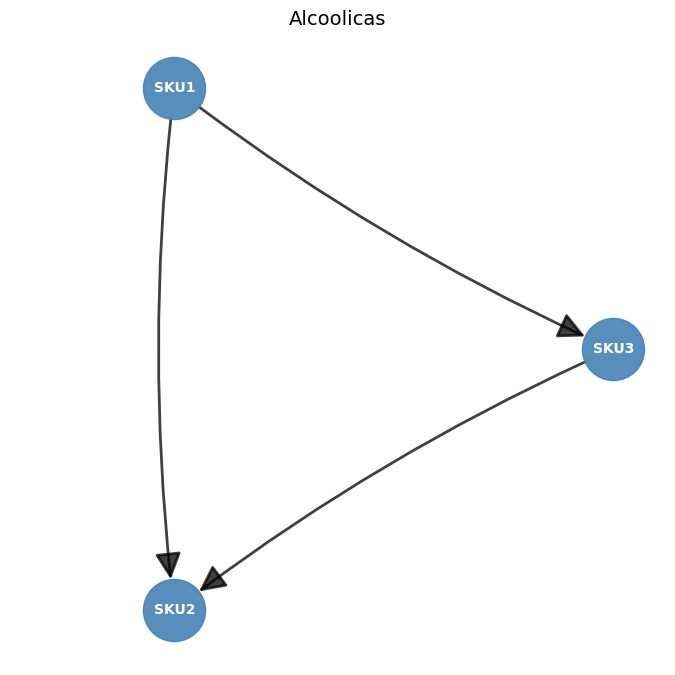

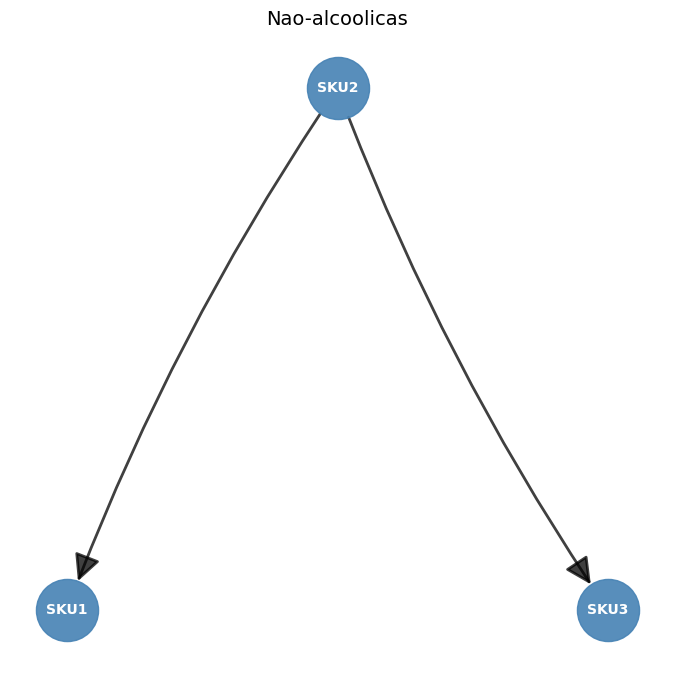

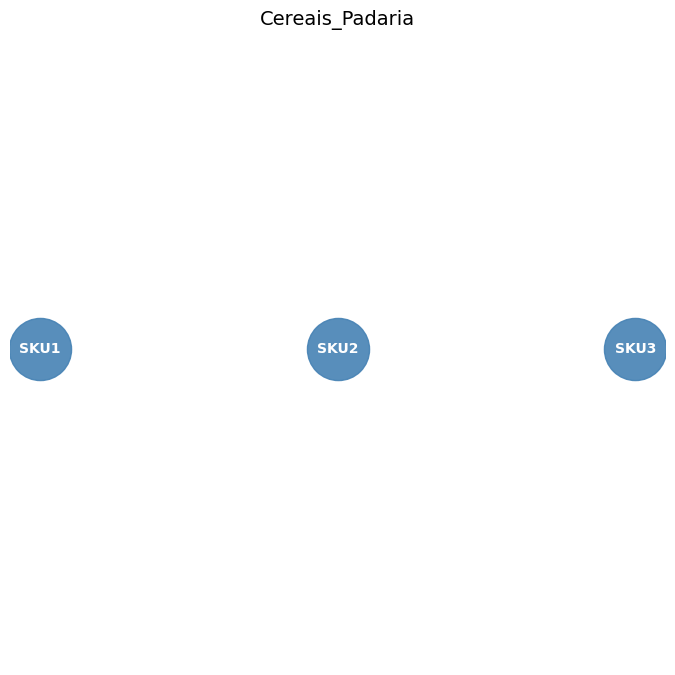

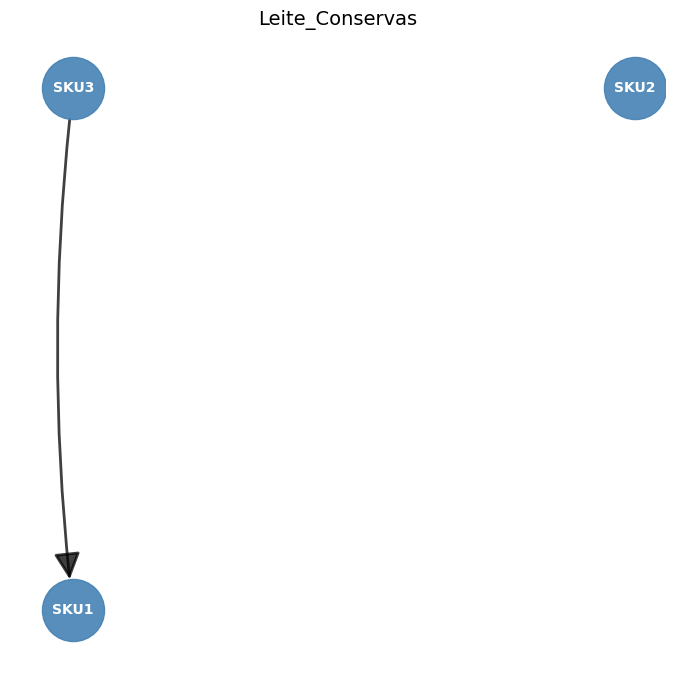

In [2]:
NBF = 10
individuals = fit_individual_structures(
    subjects,
    method="hc",
    nbf=NBF,
    node_names=node_names,
    subject_ids=subject_ids,
    n_jobs=-1,
    verbose=False,
)

for m, sid in zip(individuals, subject_ids):
    plot_dag(m, plot_type="graph", title=sid)
    plt.show()


## Anomaly detection on individual MDMs

Flag observations outside the one-step Student-t predictive interval
(`detect_anomalies`). `plot_anomalies` draws the observed series, predictive
mean, interval band, and marks outliers with `x`. We show the first node for
each subject.

Alcoolicas / SKU1: 7 anomalies (ci=0.95)


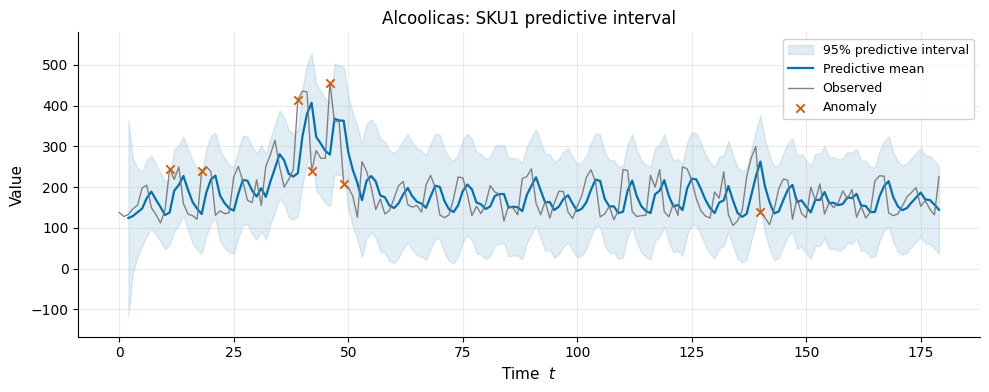

Nao-alcoolicas / SKU1: 8 anomalies (ci=0.95)


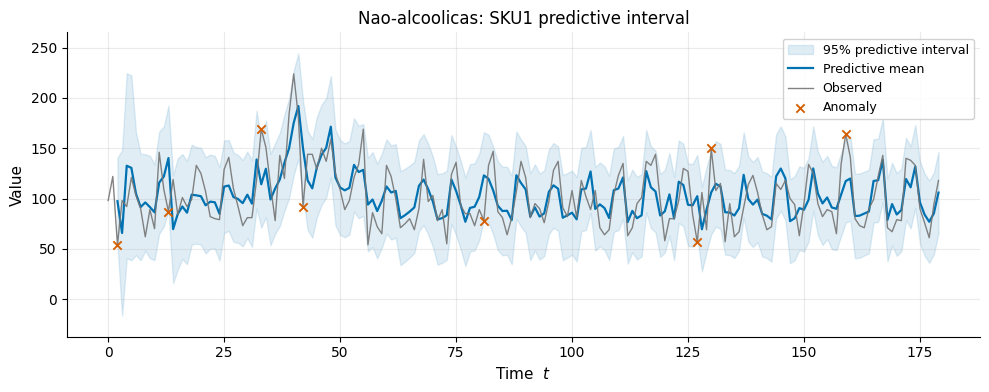

Cereais_Padaria / SKU1: 3 anomalies (ci=0.95)


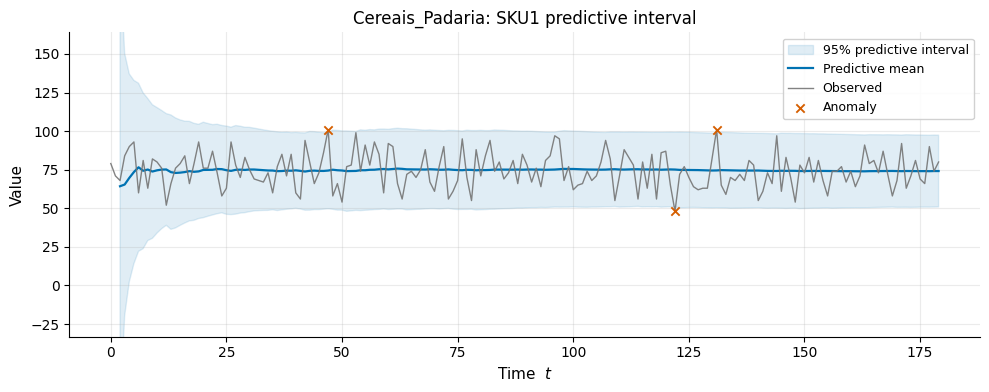

Leite_Conservas / SKU1: 6 anomalies (ci=0.95)


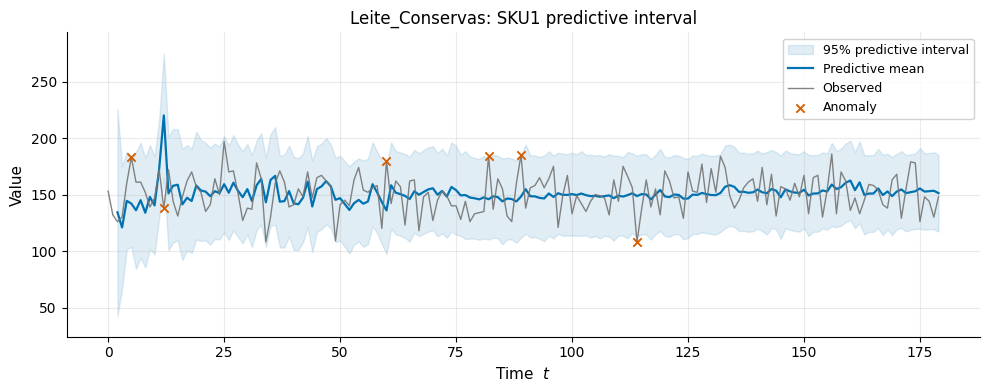

In [3]:
CI_LEVEL = 0.95
series0 = node_names[0]

for m, sid in zip(individuals, subject_ids):
    res = detect_anomalies(m, series=series0, ci_level=CI_LEVEL)
    n_flagged = int(res.is_anomaly.sum())
    print(f"{sid} / {series0}: {n_flagged} anomalies (ci={CI_LEVEL})")
    plot_anomalies(m, series=series0, ci_level=CI_LEVEL, show_observed_markers=False)
    plt.gca().set_title(f"{sid}: {series0} predictive interval")
    plt.show()


## Group-structure distance

Pairwise log-Bayes-factor separation between subject models. Larger values mean
more dissimilar dynamic structures.


In [4]:
dist = compute_mdm_distance(
    individuals,
    metric="lpl_separation",
    subject_ids=subject_ids,
    verbose=False,
)
print(pd.DataFrame(dist.matrix, index=subject_ids, columns=subject_ids).round(2))


                 Alcoolicas  Nao-alcoolicas  Cereais_Padaria  Leite_Conservas
Alcoolicas             0.00            5.08             8.82            11.11
Nao-alcoolicas         5.08            0.00            15.01            18.65
Cereais_Padaria        8.82           15.01             0.00             4.31
Leite_Conservas       11.11           18.65             4.31             0.00


## Dendrogram and embedding

Inspect the hierarchy visually. The cut that defines clusters should match what
you see in the dendrogram (here we will choose two clusters).


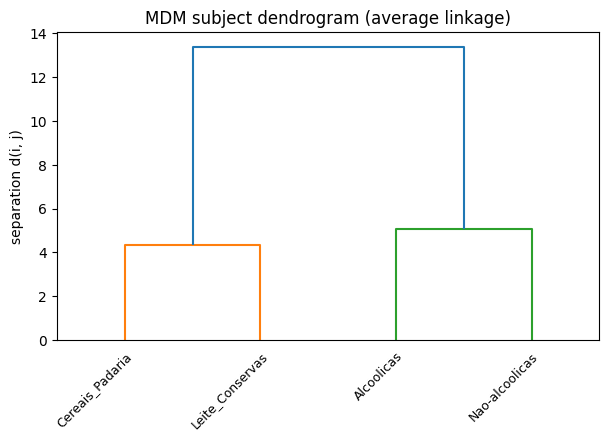

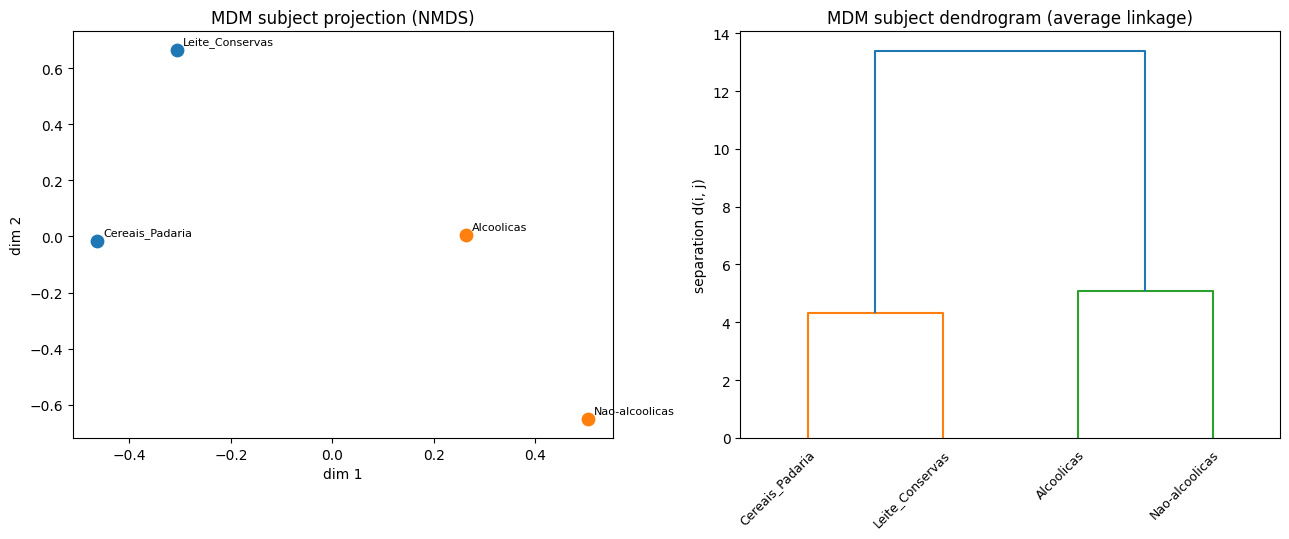

In [5]:
plot_dendrogram(dist)
plt.show()

plot_group_embedding(dist, technique="nmds", n_clusters=2, random_state=0)
plt.show()


## Choose two clusters

After inspecting the dendrogram, cut into two flat clusters. Labels come from
hierarchical clustering on the GS distance (`cluster_labels`).


In [6]:
N_CLUSTERS = 2
labels = dist.cluster_labels(N_CLUSTERS)
cluster_members = {
    int(c): [sid for sid, lab in zip(subject_ids, labels) if lab == c]
    for c in sorted(set(labels))
}
print("cluster membership:", cluster_members)


cluster membership: {1: ['Cereais_Padaria', 'Leite_Conservas'], 2: ['Alcoolicas', 'Nao-alcoolicas']}


## VTS and IS for each cluster

For every cluster, take only its members and compute:

- **VTS** — mean representative series, then one MDM
- **IS** — aggregate the already-fitted subject MDMs in that cluster


In [7]:
cluster_results = {}
for c, members in cluster_members.items():
    idx = [subject_ids.index(sid) for sid in members]
    sub_subjects = [subjects[i] for i in idx]
    sub_models = [individuals[i] for i in idx]

    vts = compute_vts(sub_subjects, method="mean")
    vts_df = pd.DataFrame(vts.vts_data, columns=node_names)
    vts_mdm = MDM(vts_df, method="hc", nbf=NBF, verbose=False, n_jobs=-1)

    is_view = aggregate_individual_structures(
        sub_models,
        tau=0.5,
        mc_n_samples=0,
        node_names=node_names,
    )
    cluster_results[c] = {
        "members": members,
        "vts_mdm": vts_mdm,
        "is_view": is_view,
    }
    print(f"cluster {c}: {members}")


cluster 1: ['Cereais_Padaria', 'Leite_Conservas']


cluster 2: ['Alcoolicas', 'Nao-alcoolicas']


## Compare cluster-level structures

Side-by-side DAGs for VTS and IS within each cluster. Different clusters can
support different group networks.


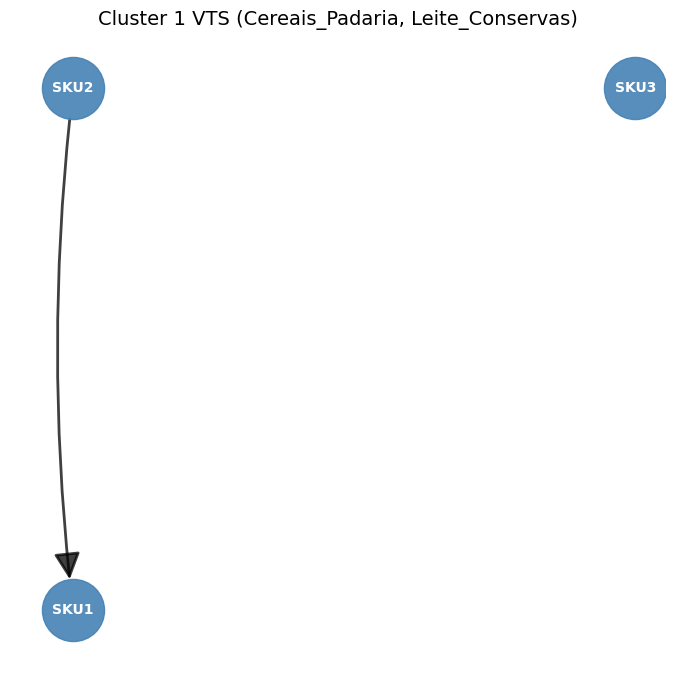

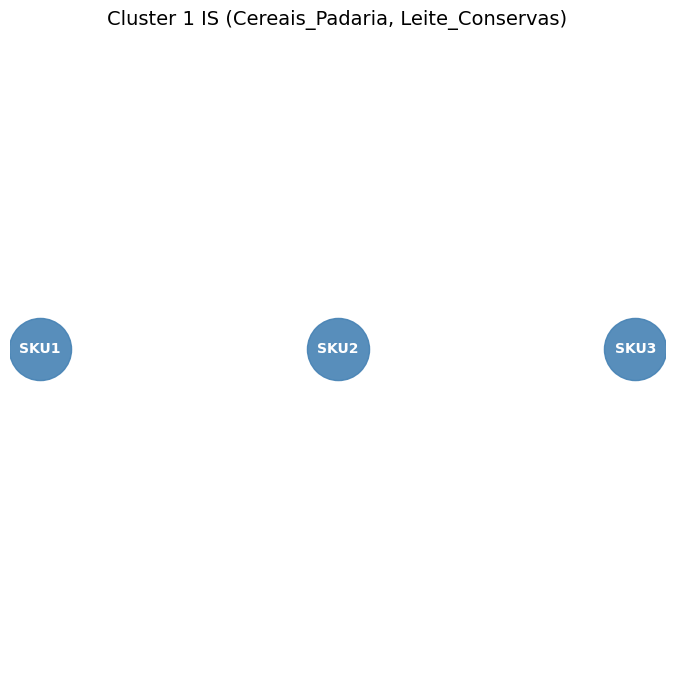

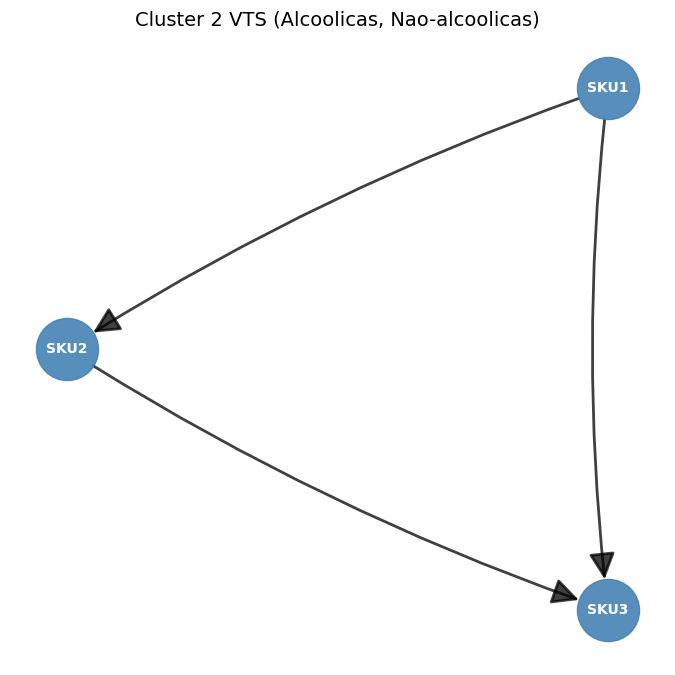

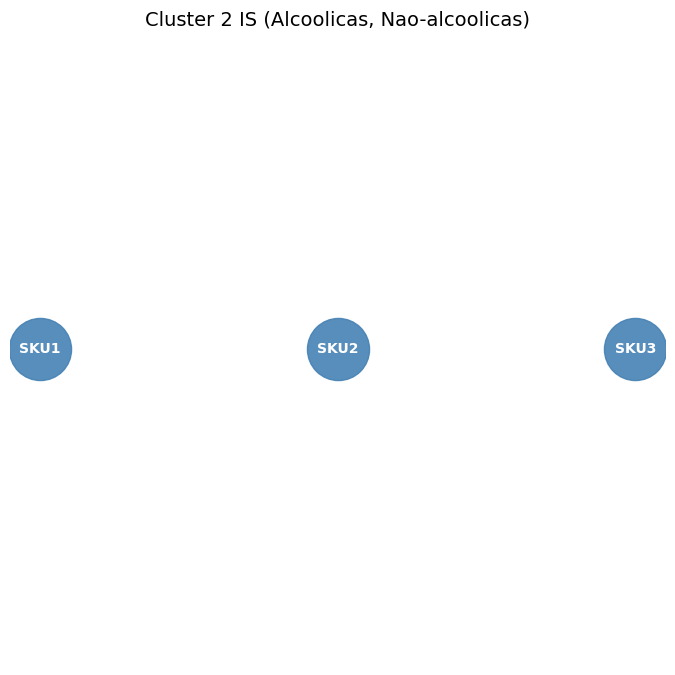

In [8]:
for c, res in sorted(cluster_results.items()):
    members = ", ".join(res["members"])
    plot_dag(
        res["vts_mdm"],
        plot_type="graph",
        title=f"Cluster {c} VTS ({members})",
    )
    plt.show()
    plot_dag(
        res["is_view"],
        plot_type="graph",
        title=f"Cluster {c} IS ({members})",
    )
    plt.show()


## Anomalies on cluster VTS models

Apply the same predictive-interval check to each cluster's VTS MDM. This shows
where the representative series for a cluster falls outside its one-step forecast
band.

cluster 1 VTS (Cereais_Padaria, Leite_Conservas) / SKU1: 7 anomalies


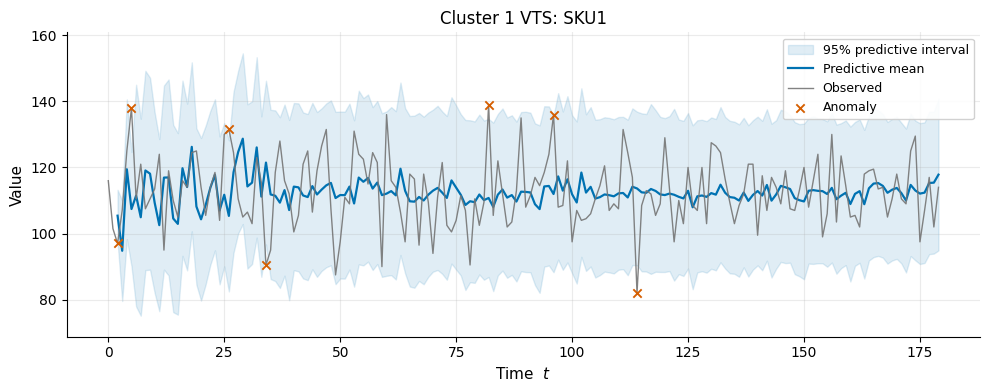

cluster 2 VTS (Alcoolicas, Nao-alcoolicas) / SKU1: 4 anomalies


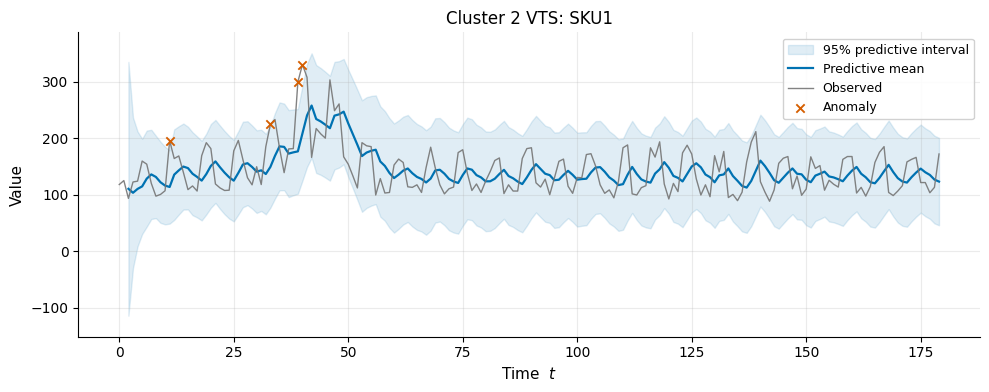

In [9]:
for c, res in sorted(cluster_results.items()):
    m = res["vts_mdm"]
    members = ", ".join(res["members"])
    anom = detect_anomalies(m, series=series0, ci_level=CI_LEVEL)
    print(
        f"cluster {c} VTS ({members}) / {series0}: "
        f"{int(anom.is_anomaly.sum())} anomalies"
    )
    plot_anomalies(m, series=series0, ci_level=CI_LEVEL, show_observed_markers=False)
    plt.gca().set_title(f"Cluster {c} VTS: {series0}")
    plt.show()
